In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from src.components.Battery import Battery

In [4]:
from src.components.DieselGenerator import DieselGenerator

In [5]:
Battery.__dict__

mappingproxy({'__module__': 'src.components.Battery',
              '__doc__': '\n    Класс моделирования системы накопления электрической энергии (СНЭЭ)\n    A class that models a battery energy storage system (BESS).\n    ',
              '__init__': <function src.components.Battery.Battery.__init__(self, capacity: float, soc_max: float, soc_min: float, r_power_ch: float, r_power_ds: float, eff_ch: float, eff_ds: float, cp: float)>,
              'get_passport_parameters': <function src.components.Battery.Battery.get_passport_parameters(self) -> dict>,
              'charge': <function src.components.Battery.Battery.charge(self, net_power: float, soc: float) -> tuple[float, float, float]>,
              'discharge': <function src.components.Battery.Battery.discharge(self, net_power: float, soc: float) -> tuple[float, float, float]>,
              'soc_status': <function src.components.Battery.Battery.soc_status(self, soc: float) -> str>,
              '__dict__': <attribute '__dict__

In [6]:
DieselGenerator.__dict__

mappingproxy({'__module__': 'src.components.DieselGenerator',
              '__doc__': '\n    Класс моделирования работы дизель-генератора\n    A class that models a diesel generator (DG).\n    ',
              '__init__': <function src.components.DieselGenerator.DieselGenerator.__init__(self, num_DGs: int, r_capacity: float, a1: float, a2: float, start_stop_price: float, fuel_price: float)>,
              'get_DGs': <function src.components.DieselGenerator.DieselGenerator.get_DGs(self) -> numpy.ndarray>,
              'calculate_fuel_consumption': <function src.components.DieselGenerator.DieselGenerator.calculate_fuel_consumption(self, generate_array: numpy.ndarray, p: float = 860.0, k: float = 1.45) -> Tuple[numpy.ndarray, numpy.ndarray]>,
              'total_cost': <function src.components.DieselGenerator.DieselGenerator.total_cost(self, power: numpy.ndarray, u: numpy.ndarray, u_prev: numpy.ndarray, r_electricity: float) -> float>,
              'optimize_DGs': <function src.compon

In [7]:
df = pd.read_excel(r'C:\Users\Илья\PycharmProjects\masters-thesis\src\data\data.xlsx')
print(df)

                datetime   Сасыр, kW  Solal, kW
0    2019-01-01 00:00:00  201.000791        0.0
1    2019-01-01 01:00:00  179.721422        0.0
2    2019-01-01 02:00:00  171.304978        0.0
3    2019-01-01 03:00:00  173.068636        0.0
4    2019-01-01 04:00:00  159.528222        0.0
...                  ...         ...        ...
8755 2019-12-31 19:00:00  277.786301        0.0
8756 2019-12-31 20:00:00  238.908277        0.0
8757 2019-12-31 21:00:00  240.645576        0.0
8758 2019-12-31 22:00:00  200.358556        0.0
8759 2019-12-31 23:00:00  183.208797        0.0

[8760 rows x 3 columns]


In [8]:
capacity = 200
soc_max = 100
soc_min = 20
r_power_ch = 50
r_power_ds = 45
eff_ch = 98
eff_ds = 98
cp = 2
BESS = (
    Battery(capacity= capacity,
        soc_max = soc_max,
        soc_min = soc_min,
        r_power_ch = r_power_ch,
        r_power_ds = r_power_ds,
        eff_ch = eff_ch,
        eff_ds = eff_ds,
        cp = cp))

In [9]:
num_DGs = 5
r_capacity = 110
a1, a2 = 0.0101, 0.2654
start_stop_price = 200
fuel_price = 27
DGs = (
    DieselGenerator(num_DGs = num_DGs,
                      r_capacity = r_capacity,
                      a1 = a1, a2 = a2,
                      start_stop_price = start_stop_price,
                      fuel_price = fuel_price))

In [ ]:
DGs

In [16]:
DGs.optimize_DGs(np.array([1,1,0,0,0]),0, 27.0)

(array([38.5,  0. ,  0. ,  0. ,  0. ]),
 array([1, 0, 0, 0, 0]),
 np.float64(0.24529294306335206),
 np.float64(38.5),
 np.int64(2))

In [18]:
u_dgs = np.array([1,1,0,0,0])
u_prev = np.zeros_like(u_dgs)
cost_dgs = DGs.total_cost(u_prev, u_dgs, u_prev,
                                           27.0)
cost_dgs

np.float64(400.0)

In [10]:
from src.simulator.MicrogridSimulator import MicrogridSimulator
MS = MicrogridSimulator(df,
                        'Сасыр, kW',
                        'Solal, kW',
                         BESS,
                         DGs,
                         27.0)
resilts = MS.simulator_1(0.5,np.array([1,1,0,0,0], dtype=np.float64))

In [11]:
resilts

{'new_gen': array([0., 0., 0., ..., 0., 0., 0.], shape=(8760,)),
 'capacity_history': array([100.        ,  50.08163265,  40.08163265, ...,  40.08163265,
         40.08163265,  40.08163265], shape=(8761,)),
 'soc_history': array([0.5       , 0.25040816, 0.20040816, ..., 0.20040816, 0.20040816,
        0.20040816], shape=(8761,)),
 'new_net_power': array([201.00079137, 179.72142183, 171.30497811, ..., 240.64557608,
        200.35855629, 183.20879694], shape=(8760,)),
 'final_u_dgs': array([1, 1, 1, 1, 0]),
 'p_bess_history': array([45.  ,  5.88,  0.  , ...,  0.  ,  0.  ,  0.  ], shape=(8760,)),
 'p_dgs_history': array([156.00079137, 173.84142183, 171.30497811, ..., 240.64557608,
        200.35855629, 183.20879694], shape=(8760,)),
 'cost_dgs_history': array([400.99266918,   1.09518914,   1.08061364, ...,   1.50312997,
          1.27162337,   1.14901812], shape=(8760,))}

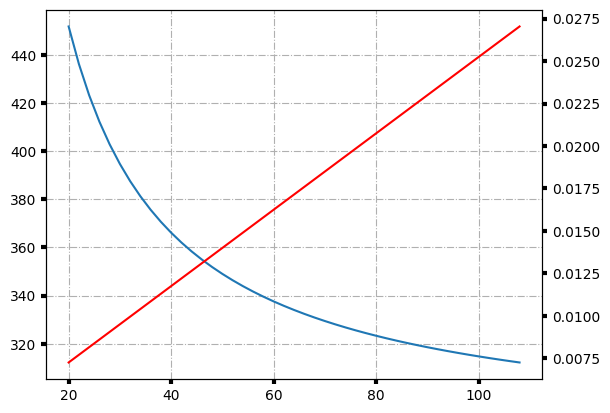

In [6]:
Qp = 10180
bnom = 210
eff_nom = 0.98
N_nom = 110
p = 860

N = np.arange(20, 110, 2)
b = bnom / eff_nom * (0.9 + 0.1/(N/N_nom)) * Qp/7000
Q = b * N / (1e3*(1.45 * p))
fig, ax1 = plt.subplots()
ax1.plot(N, b)
ax1.grid(True, linestyle='-.')
ax1.tick_params(labelsize='medium', width=3)

ax2 = ax1.twinx()
ax2.plot(N, Q,'r')
ax2.tick_params(labelsize='medium', width=3)

plt.show()

In [19]:
load = df['Сасыр, kW'].to_numpy()
gen = df['Solal, kW'].to_numpy()
# Инициализация
n = len(gen)
r_electricity = 27
new_gen = gen # Новая мощность ФЭС
Capacity = np.zeros(n + 1, dtype=np.float64) # Состояние заряда батареи
soc = np.zeros(n + 1, dtype=np.float64) # Состояние заряда батареи
new_net_power = np.zeros(n + 1, dtype=np.float64) #Новый баланс мощность
# Начальные значения
soc[0] = 0.5
Capacity[0] = soc[0] * capacity
status = BESS.soc_status(soc[0])
u_DGs = np.array([1,1,0,0,0], dtype=np.float64)
for t in range(n):
    net_power = gen[t] - load[t]
    if net_power >= 0: # Энергия ФЭС больше или равна нагрузке
        if status in ['Заряд и Разряд возможен', 'Разряд невозможен']:
            p_bess, Capacity[t+1], soc[t+1] = BESS.charge(net_power, soc[t]) # СНЭЭ заряжается от ФЭС
            new_net_power[t] = net_power + p_bess # Новый баланс мощности
        else:  # Балласт от ФЭС
            p_bess, Capacity[t+1], soc[t+1] = 0, Capacity[t], soc[t] # СНЭЭ НЕ заряжается от ФЭС
            new_gen[t] = load[t] # Мощность ФЭС снижается до необходимой
            new_net_power[t] = 0 # Новый баланс мощности

    else:  # Энергия ФЭС меньше нагрузки
        if status in ['Заряд и Разряд возможен', 'Заряд невозможен']:
            p_bess, Capacity[t+1], soc[t+1] = BESS.discharge(-net_power, soc[t]) # СНЭЭ разряжается
            if net_power + p_bess == 0: # Энергоемкости СНЭЭ достаточно для покрытия остаточной нагрузки
                new_net_power[t] = net_power + p_bess # Новый баланс мощности
            else:
                p_DGs, u_DGs, cost_DGs, total_p, is_on = DGs.optimize_DGs(u_DGs, -net_power - p_bess, r_electricity) # Оптимальная загрузка генератора
                new_net_power[t] = net_power + p_bess # Новый баланс мощности
        else: # Разряд невозможен
            p_DGs, u_DGs, cost_DGs, total_p, is_on = DGs.optimize_DGs(u_DGs, -net_power, r_electricity) # Оптимальная загрузка генератора
            new_net_power[t] = net_power # Новый баланс мощности

In [24]:
import numpy as np
import pandas as pd
from typing import Tuple, Dict, Optional

def optimize_energy_system(
    df: pd.DataFrame,
    load_column: str,
    gen_column: str,
    capacity: float,
    bess: object,
    dgs: object,
    r_electricity: float = 27.0,
    initial_soc: float = 0.5,
    u_dgs: Optional[np.ndarray] = None
    ) -> Dict[str, np.ndarray]:

    # Загрузка данных
    load = df[load_column].to_numpy()
    gen = df[gen_column].to_numpy()

    # Проверка входных данных
    if len(load) != len(gen):
        raise ValueError("Длины массивов нагрузки и генерации должны совпадать")

    if not 0 <= initial_soc <= 1:
        raise ValueError("Начальное состояние заряда должно быть в диапазоне [0, 1]")

    n = len(gen)

    # Инициализация массивов
    new_gen = gen.copy()  # Создаем копию, а не ссылку
    capacity_history = np.zeros(n + 1, dtype=np.float64)
    soc_history = np.zeros(n + 1, dtype=np.float64)
    new_net_power = np.zeros(n, dtype=np.float64)  # Только n элементов
    p_bess_history = np.zeros(n, dtype=np.float64)
    p_dgs_history = np.zeros(n, dtype=np.float64)
    cost_dgs_history = np.zeros(n, dtype=np.float64)

    # Начальные условия
    soc_history[0] = initial_soc
    capacity_history[0] = initial_soc * capacity

    for t in range(n):
        current_soc = soc_history[t]
        status = bess.soc_status(current_soc)
        net_power = gen[t] - load[t]

        if net_power >= 0:
            if status in ['Заряд и Разряд возможен', 'Разряд невозможен']:
                p_bess, capacity_next, soc_next = bess.charge(net_power, current_soc)
                new_net_power[t] = net_power + p_bess
            else:
                p_bess, capacity_next, soc_next = 0.0, capacity_history[t], current_soc
                new_gen[t] = load[t]
                new_net_power[t] = 0.0
        else:
            if status in ['Заряд и Разряд возможен', 'Заряд невозможен']:
                p_bess, capacity_next, soc_next = bess.discharge(-net_power, current_soc)
                if net_power + p_bess == 0:
                    new_net_power[t] = net_power + p_bess
                else:
                    p_dgs, u_dgs, cost_dgs, total_p, is_on = dgs.optimize_DGs(
                        u_dgs, -net_power - p_bess, r_electricity
                    )
                    p_dgs_history[t] = total_p
                    cost_dgs_history[t] = cost_dgs
                    new_net_power[t] = total_p + p_bess
            else:
                p_bess = 0.0
                capacity_next, soc_next = capacity_history[t], current_soc
                p_dgs, u_dgs, cost_dgs, total_p, is_on = dgs.optimize_DGs(
                    u_dgs, -net_power, r_electricity
                )
                p_dgs_history[t] = total_p
                cost_dgs_history[t] = cost_dgs
                new_net_power[t] = net_power + p_dgs

        # Единый блок записи истории BESS
        p_bess_history[t] = p_bess
        capacity_history[t + 1] = capacity_next
        soc_history[t + 1] = soc_next

    return {
        'new_gen': new_gen,
        'capacity_history': capacity_history,
        'soc_history': soc_history,
        'new_net_power': new_net_power,
        'final_u_dgs': u_dgs,
        'p_bess_history': p_bess_history,
        'p_dgs_history': p_dgs_history,
        'cost_dgs_history': cost_dgs_history
    }

In [25]:
resilts = optimize_energy_system(
    df,
    'Сасыр, kW',
    'Solal, kW',
    BESS.get_passport_parameters()['Номинальная энергоемкость (кВт·ч)'],
    BESS,
    DGs,
    27.0,
    0.5,
    np.array([1,1,0,0,0], dtype=np.float64))

In [26]:
resilts

{'new_gen': array([0., 0., 0., ..., 0., 0., 0.], shape=(8760,)),
 'capacity_history': array([100.        ,  50.08163265,  40.08163265, ...,  40.08163265,
         40.08163265,  40.08163265], shape=(8761,)),
 'soc_history': array([0.5       , 0.25040816, 0.20040816, ..., 0.20040816, 0.20040816,
        0.20040816], shape=(8761,)),
 'new_net_power': array([201.00079137, 179.72142183, 171.30497811, ..., 240.64557608,
        200.35855629, 183.20879694], shape=(8760,)),
 'final_u_dgs': array([1, 1, 1, 1, 0]),
 'p_bess_history': array([45.  ,  5.88,  0.  , ...,  0.  ,  0.  ,  0.  ], shape=(8760,)),
 'p_dgs_history': array([156.00079137, 173.84142183, 171.30497811, ..., 240.64557608,
        200.35855629, 183.20879694], shape=(8760,)),
 'cost_dgs_history': array([400.99266918,   1.09518914,   1.08061364, ...,   1.50312997,
          1.27162337,   1.14901812], shape=(8760,))}